# :Advanced Statistical Analysis of Apple Inc. Stock Data

This involves analysing financial data to design an effective visualisation and conducting hypothesis testing on the dataset.

### 1. Data Loading and Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/Apple Stock Prices (1981 to 2023).csv')

In [ ]:
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200
...,...,...,...,...,...,...,...
10603,23/01/2023,138.119995,143.320007,137.899994,141.110001,141.110001,81760300
10604,24/01/2023,140.309998,143.160004,140.300003,142.529999,142.529999,66435100
10605,25/01/2023,140.889999,142.429993,138.809998,141.860001,141.860001,65799300
10606,26/01/2023,143.169998,144.250000,141.899994,143.960007,143.960007,54105100


In [ ]:
print("Dataset Shape:", data.shape)
print("\nColumn Names:")
print(data.columns.tolist())

Dataset Shape: (10608, 7)

Column Names:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  object 
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 580.3+ KB


The Date column is of type Object

In [ ]:
#Change the type of the Date column

data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10608 non-null  datetime64[ns]
 1   Open       10608 non-null  float64       
 2   High       10608 non-null  float64       
 3   Low        10608 non-null  float64       
 4   Close      10608 non-null  float64       
 5   Adj Close  10608 non-null  float64       
 6   Volume     10608 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 580.3 KB


In [ ]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


No missing values were found

### 2. Data Visualization

* Changes in Apple's closing price

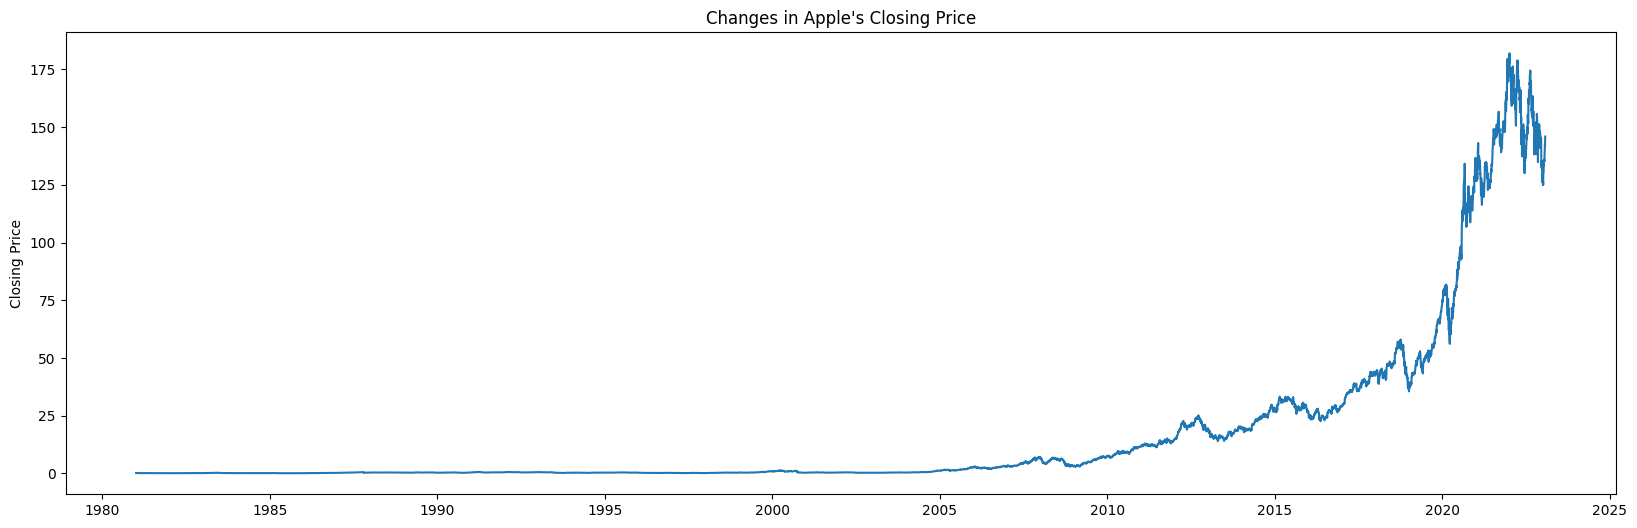

In [ ]:
plt.figure(figsize=(20, 6))
sns.lineplot(data=data, x='Date', y='Close')
plt.xlabel('')
plt.ylabel('Closing Price')
plt.title('Changes in Apple\'s Closing Price')
plt.show()

There is a strong long-term upward trend, which is typical of large-cap growth technology stocks.
Investing in this stock presents a real opportunity.

* Analysis of Trading Volume

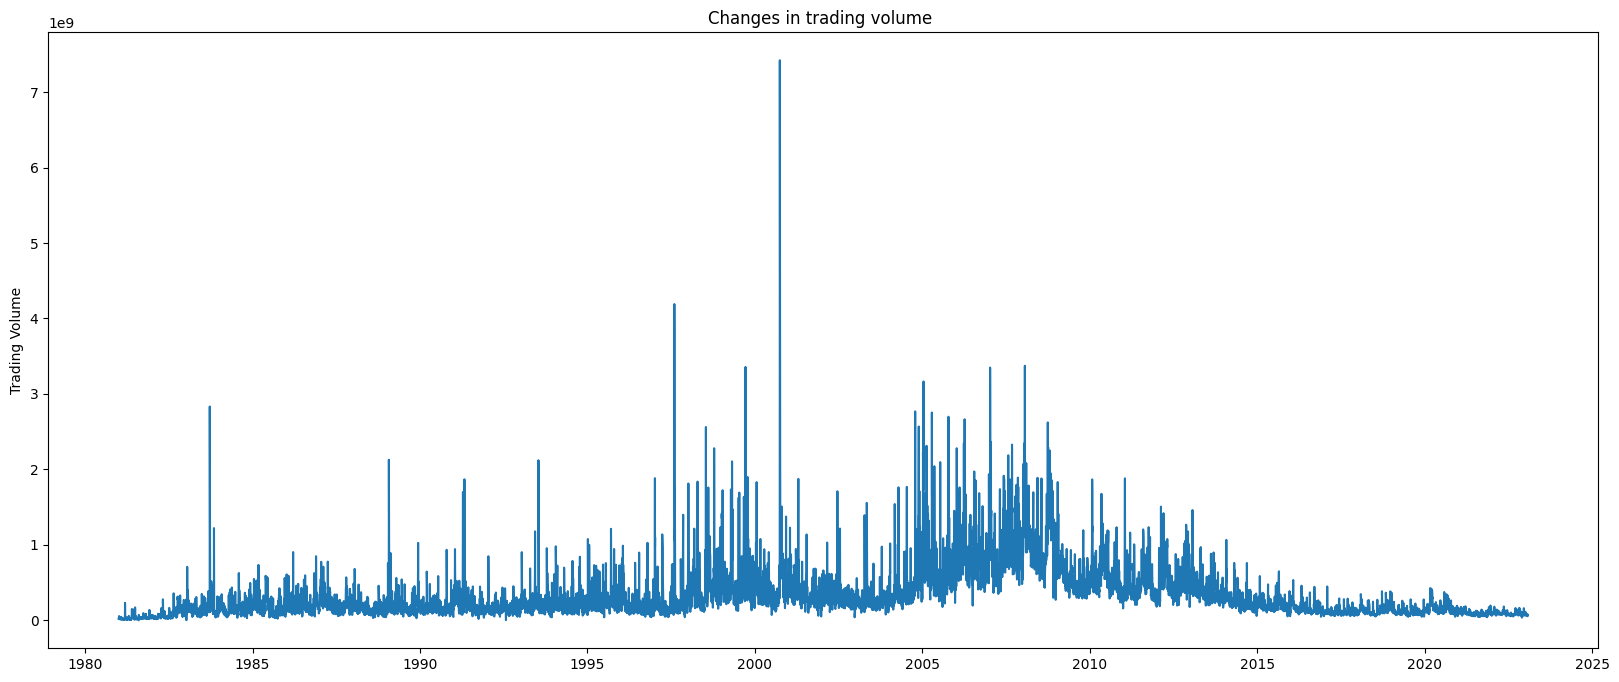

In [ ]:
plt.figure(figsize=(20, 8))
sns.lineplot(data=data, x='Date', y='Volume')
plt.xlabel('')
plt.ylabel('Trading Volume')
plt.title("Changes in trading volume ")
plt.show()

The transaction volume chart reveals several phases.
Low-activity phase: Until the 2000s, volume remained relatively low.
Peak phase: Massive peaks in volume were observed around 2008–2012 and around 2020.
High-volume phase: Volume has remained consistently high in recent years.

In [ ]:
import plotly.graph_objects as go

recent_data = data.tail(100)

plt.figure(figsize=(20, 6))

fig = go.Figure(data=[go.Candlestick(x=recent_data['Date'],
                open=recent_data['Open'],
                high=recent_data['High'],
                low=recent_data['Low'],
                close=recent_data['Close'])])

fig.update_layout(
    title='Apple candlestick chart',
    yaxis_title='Price ($)',
    xaxis_title='',
    xaxis_rangeslider_visible=False
)

fig.show()

<Figure size 2000x600 with 0 Axes>

The chart shows the last 100 trading days:

Green candles indicate a session where the closing price is higher than the opening price (up), whilst red candles indicate a fall.

The thin lines above and below the body represent the highest and lowest prices reached during the day. Long wicks indicate high intraday volatility.

We can see whether the price is following a trend of higher and higher highs or whether there are signs of a reversal

The average height of these candles corresponds to the high standard deviation we observed previously, confirming that Apple shares are subject to significant daily price fluctuations.

### 3. Statistical Analysis

In [ ]:
data.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,10608,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,2002-01-05 14:08:33.122171904,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
min,1981-01-02 00:00:00,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,1991-06-27 18:00:00,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,2002-01-02 12:00:00,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,2012-07-13 18:00:00,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,2023-01-27 00:00:00,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09
std,NaN,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08


Comment:
- **Column: Open / High / Low / Close**:  It can be seen that the 75th percentile values (16.26) are still a long way from the maximum (182.00), which confirms that the main rise is concentrated towards the end of the period.

- **Adj Close column**: This distribution closely follows that of the “Close”.

- **Volume**: The minimum value is 0, which can occur during trading halts. The very high average confirms that Apple is one of the most traded shares in the world.
- The average closing price of the share is: 16.69 , confirming a mature growth phase.
- The standard deviation of the share price at the close is high; the price fluctuates significantly. The high standard deviation seen in the table is reflected graphically by the gap between the actual price and the smoothed moving average lines.

### 4. Hypothesis Testing

Question : Are the average prices for 2022 and 2023 different ?

In [ ]:
price_2022 = data[data['Date'].dt.year == 2022]['Close']
price_2023 = data[data['Date'].dt.year == 2023]['Close']

In [ ]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(price_2022, price_2023)

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis, The average prices differ significantly.")
else:
    print("Fail to reject the null hypothesis, No statistically significant difference was observed.")

Reject the null hypothesis, The average prices differ significantly.


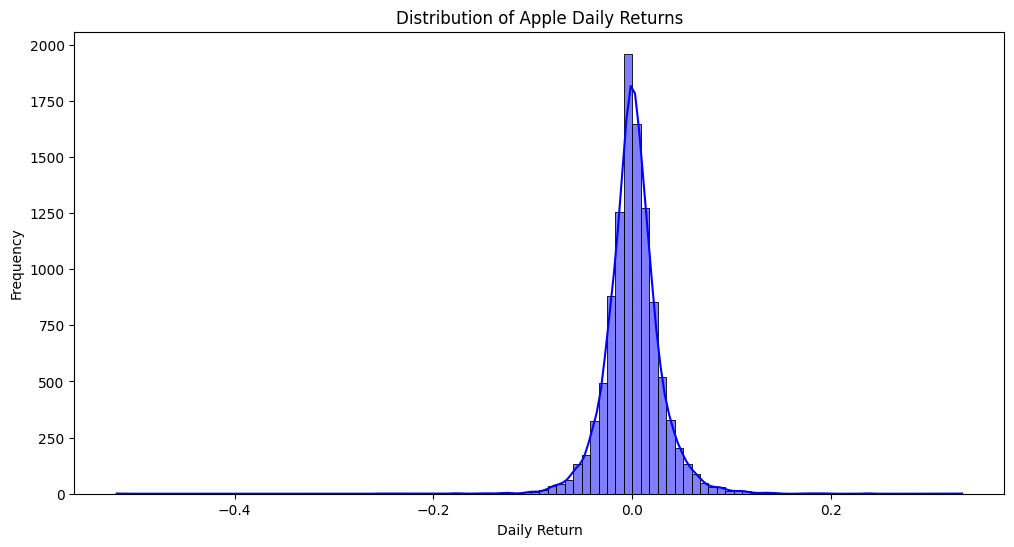

Normality Test Statistic: 2719.2053, p-value: 0.0000
Reject the null hypothesis: The daily returns do not follow a normal distribution.


In [39]:
from scipy.stats import normaltest


data['Daily_Return'] = data['Close'].pct_change().dropna()


plt.figure(figsize=(12, 6))
sns.histplot(data['Daily_Return'], kde=True, bins=100, color='blue')
plt.title('Distribution of Apple Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()


stat, p = normaltest(data['Daily_Return'].dropna())
print(f'Normality Test Statistic: {stat:.4f}, p-value: {p:.4f}')

alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: The daily returns do not follow a normal distribution.")
else:
    print("Fail to reject the null hypothesis: The daily returns follow a normal distribution.")

### 5. Advanced Statistical Techniques (Bonus)**bold text**

In [ ]:
correlation = np.corrcoef(
    data['Close'],
    data['Volume']
)

print(correlation)

[[ 1.         -0.21493343]
 [-0.21493343  1.        ]]


The correlation of -0.21 between price and volume

trading volume does not predictably dictate Apple’s price.

### 6. Summary and Insights

- Apple stock has shown a long-term upward trend.
Trading volumes vary significantly from period to period.
- The moving average confirms the overall trends.
- The t-test indicates a significant difference between certain years.
- The correlation between volume and price is not strong. There is no strong link between the number of shares traded and the value of Apple stock.
- Daily returns do not follow a normal distribution exactly.

### 7. Reflection

Challenges Encountered
- Creating the candlestick chart.
- Interpreting the statistical results.
Solutions Implemented
- Using Pandas to handle dates.
- Verifying statistical assumptions with SciPy.